# Loan Prediction

### Import Libraries and Load Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

df = pd.read_csv("/content/train_ctrUa4K.csv")

# Data Overview

In this section, the dataset is examined in terms of its shape, column structure, data types, and sample records to gain an initial understanding of the data.

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
print(df.columns)
print("Total column number:",len(df.columns))

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')
Total column number: 13


In [5]:
df.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0
Credit_History,564.0,0.842199,0.364878,0.0,1.0,1.0,1.00,1.0


The initial inspection shows that the dataset consists of both numerical and categorical features. This overview serves as the foundation for the following steps, including exploratory data analysis and missing value treatment

# Exploratory Data Analysis

In this section, exploratory data analysis is performed to understand the distribution of variables and the relationships among features. Numerical and categorical variables are examined separately for better interpretation.

In [7]:
df = df.drop(['Loan_ID'], axis=1)


cat_columns = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(exclude="object").columns
print(num_cols)
print(cat_columns)

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')
Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='object')


In [8]:
df.shape

(614, 12)

<Axes: >

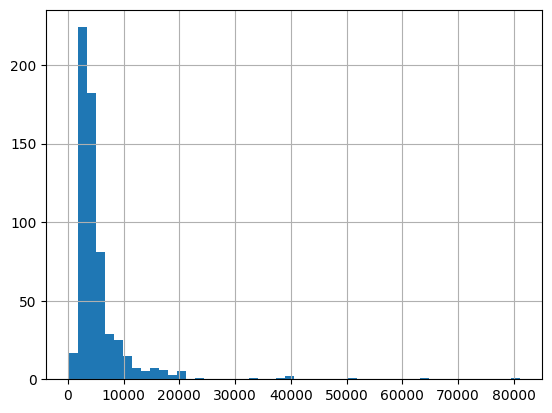

In [9]:
df['ApplicantIncome'].hist(bins=50)

In [10]:
df[df.ApplicantIncome > 50000]

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
171,NaN,Yes,3+,Graduate,No,51763,0.0,700.0,300.0,1.0,Urban,Y
333,Male,Yes,0,Graduate,NaN,63337,0.0,490.0,180.0,1.0,Urban,Y
409,Male,Yes,3+,Graduate,No,81000,0.0,360.0,360.0,0.0,Rural,N


<Axes: title={'center': 'ApplicantIncome'}, xlabel='Education'>

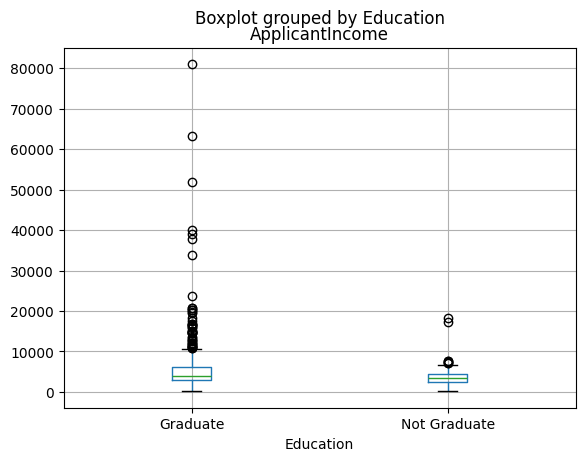

In [11]:
df.boxplot(column='ApplicantIncome', by = 'Education')

<Axes: >

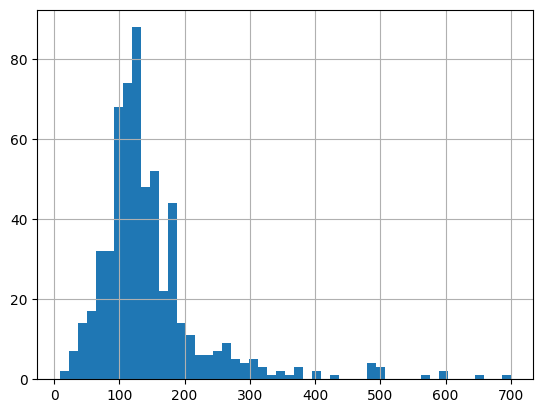

In [12]:
df["LoanAmount"].hist(bins=50)

In [13]:
df.isnull().sum()

,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


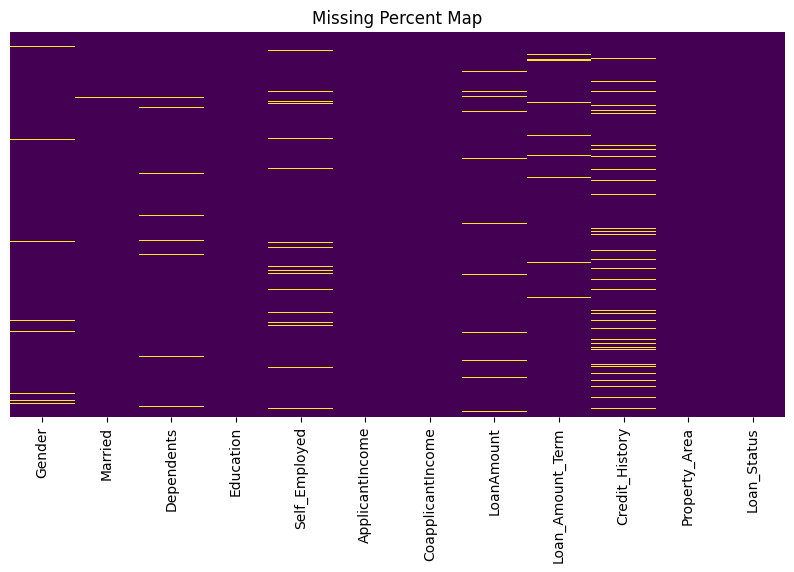

In [14]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Percent Map")
plt.show()

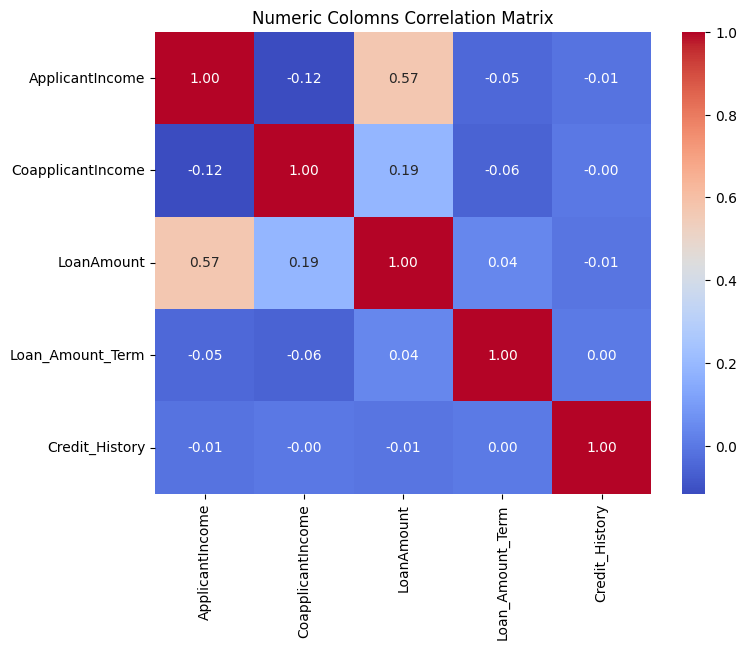

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Numeric Colomns Correlation Matrix")
plt.show()

#A correlation heatmap is used to measure the linear relationships between numerical variables and to identify potentially related features.

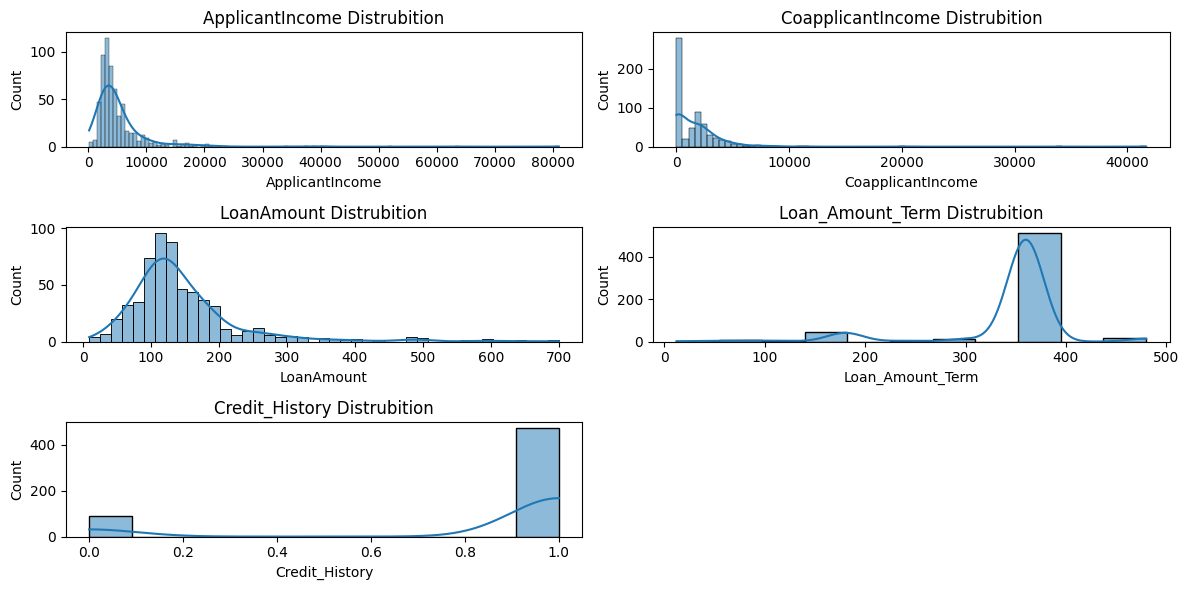

In [16]:
plt.figure(figsize=(12,6))

for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols)//2 + 1, 2, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distrubition")

plt.tight_layout()
plt.show()

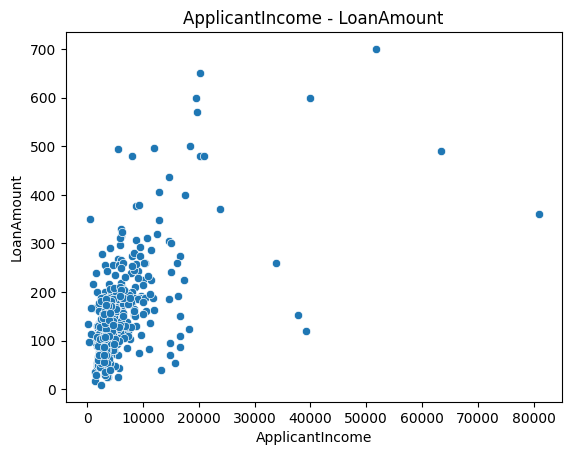

In [17]:
sns.scatterplot(x="ApplicantIncome", y="LoanAmount", data=df)
plt.title("ApplicantIncome - LoanAmount")
plt.show()

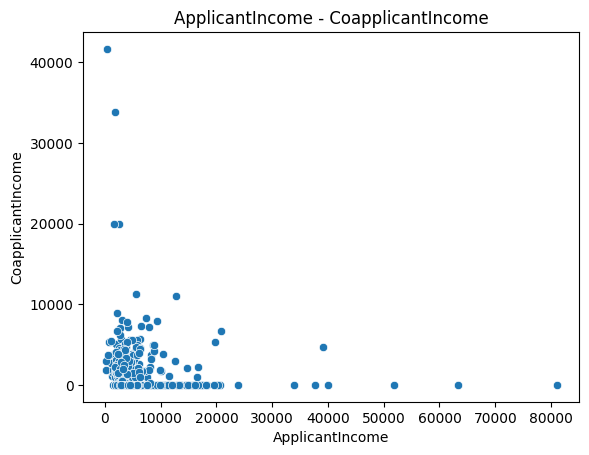

In [18]:
sns.scatterplot(x="ApplicantIncome", y="CoapplicantIncome", data=df)
plt.title("ApplicantIncome - CoapplicantIncome")
plt.show()

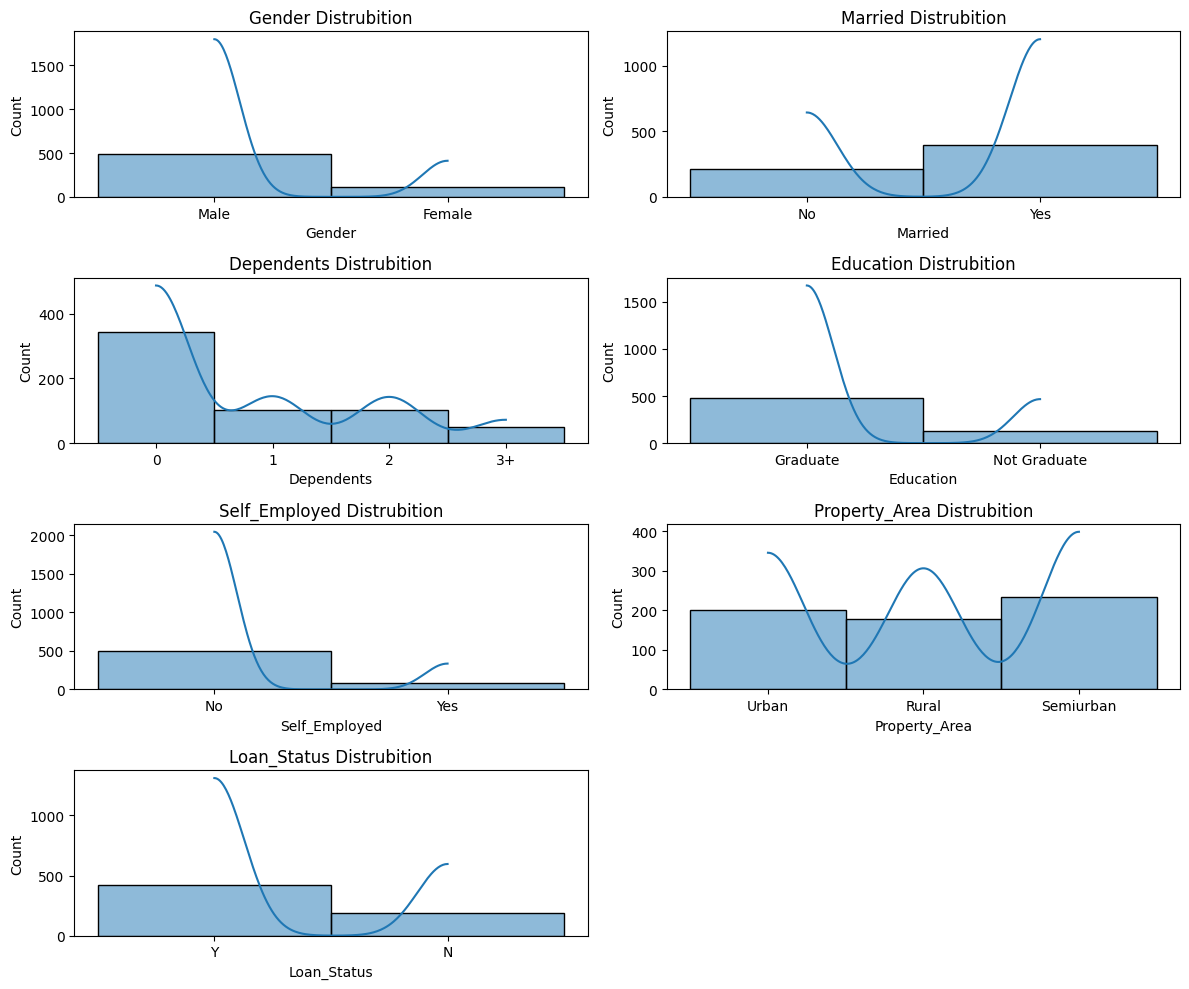

In [19]:
plt.figure(figsize=(12,10))

for i, col in enumerate(cat_columns, 1):
    plt.subplot(len(cat_columns)//2 + 1, 2, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distrubition")

plt.tight_layout()
plt.show()

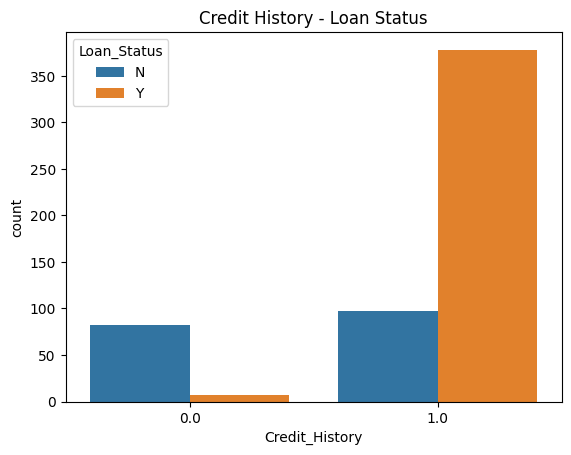

In [20]:
sns.countplot(x="Credit_History", hue="Loan_Status", data=df)
plt.title("Credit History - Loan Status")
plt.show()

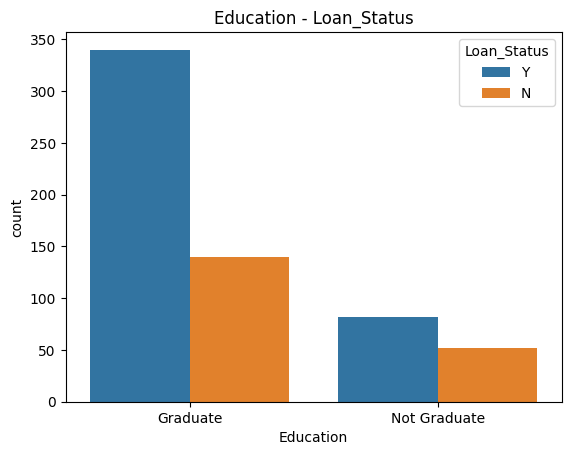

In [21]:
sns.countplot(x="Education", hue="Loan_Status", data=df)
plt.title("Education - Loan_Status")
plt.show()

In [22]:
df["total_income"] = df["ApplicantIncome"] + df["CoapplicantIncome"]
df.drop(["ApplicantIncome", "CoapplicantIncome"], axis=1, inplace=True)

Overall, the exploratory data analysis provided a clearer understanding of the dataset and highlighted meaningful relationships between variables. These observations were useful for handling missing values, creating new features, and preparing the data for machine learning models.

# Missing Value Analysis

This section focuses on identifying missing values and deciding how to handle them based on the relationships between variables. Instead of applying a single imputation method to all columns, the patterns between related features were examined to choose more appropriate filling strategies.

In [23]:
df.isnull().sum()

,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50
Property_Area,0
Loan_Status,0


In [24]:
miss_percent = df.isnull().sum()/ len(df) * 100
miss_percent.sort_values(ascending=False)

,0
Credit_History,8.143322
Self_Employed,5.211726
LoanAmount,3.583062
Dependents,2.442997
Loan_Amount_Term,2.280130
Gender,2.117264
Married,0.488599
Education,0.000000
Property_Area,0.000000
Loan_Status,0.000000


In [25]:
df[df.Credit_History.isnull()]

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,total_income
16,Male,No,1,Not Graduate,No,100.0,240.0,NaN,Urban,Y,3596.0
24,Male,Yes,1,Graduate,NaN,151.0,360.0,NaN,Semiurban,N,6642.0
30,Male,Yes,1,Graduate,NaN,201.0,360.0,NaN,Urban,N,7535.0
42,Male,Yes,0,Graduate,No,75.0,360.0,NaN,Urban,Y,2400.0
79,Male,Yes,3+,Not Graduate,Yes,130.0,360.0,NaN,Semiurban,Y,5499.0
83,Male,Yes,0,Graduate,No,265.0,360.0,NaN,Semiurban,N,8250.0
86,Male,Yes,2,Not Graduate,No,99.0,360.0,NaN,Semiurban,Y,5333.0
95,Male,No,0,Graduate,NaN,NaN,360.0,NaN,Urban,N,6782.0
117,Male,Yes,1,Graduate,No,85.0,360.0,NaN,Urban,Y,3612.0
125,Female,No,0,Graduate,No,93.0,360.0,NaN,Rural,Y,3692.0


In [26]:
df.Credit_History.value_counts()

,count
Credit_History,
1.0,475
0.0,89


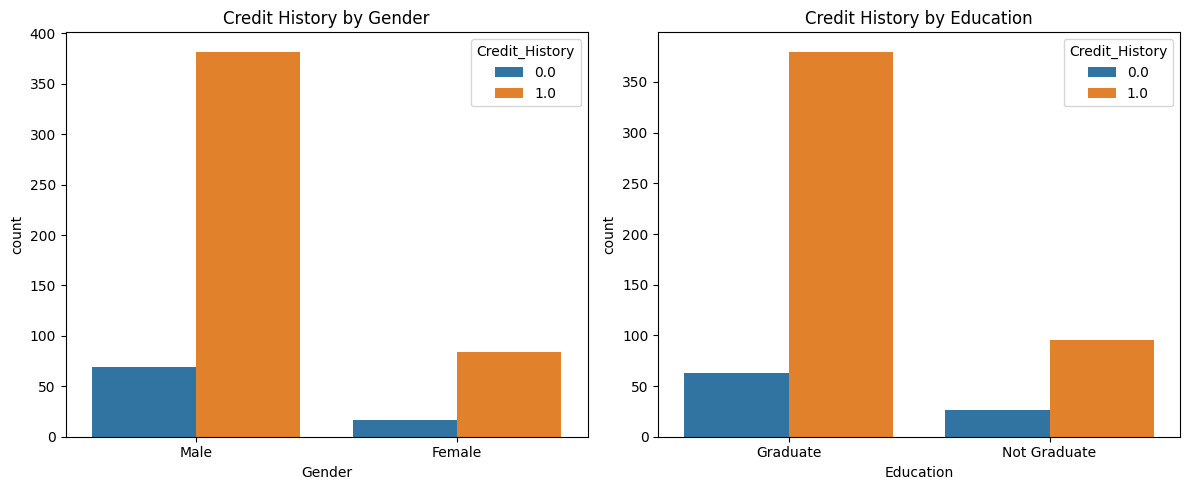

In [27]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.countplot(x="Gender", hue="Credit_History", data=df)
plt.title("Credit History by Gender")

plt.subplot(1,2,2)
sns.countplot(x="Education", hue="Credit_History", data=df)
plt.title("Credit History by Education")

plt.tight_layout()
plt.show()

In [28]:
df["Credit_History"] = df["Credit_History"].fillna(
    df.groupby(["Gender", "Education"])["Credit_History"].transform(
        lambda x: x.mode()[0] if not x.mode().empty else np.nan))

In [29]:
df[df.Credit_History.isnull()]

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,total_income
460,NaN,Yes,0,Graduate,Yes,160.0,360.0,NaN,Semiurban,Y,6166.0


In [30]:
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

In [31]:
df[df.Credit_History.isnull()]

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,total_income


In [32]:
df.isnull().sum().sort_values(ascending=False)

,0
Self_Employed,32
LoanAmount,22
Dependents,15
Loan_Amount_Term,14
Gender,13
Married,3
Education,0
Credit_History,0
Property_Area,0
Loan_Status,0


In [33]:
df.Credit_History.value_counts()

,count
Credit_History,
1.0,525
0.0,89


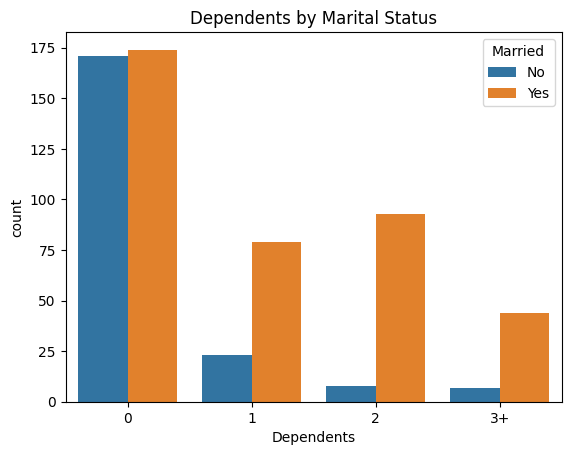

In [34]:
sns.countplot(x="Dependents", hue="Married", data=df)
plt.title("Dependents by Marital Status")
plt.show()

In [35]:
df["Dependents"] = df["Dependents"].fillna(
    df.groupby("Married")["Dependents"].transform(
        lambda x: x.mode()[0] if not x.mode().empty else np.nan))

In [36]:
df[df.Dependents.isnull()]

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,total_income
104,Male,NaN,NaN,Graduate,No,160.0,360.0,1.0,Urban,Y,4570.0
228,Male,NaN,NaN,Graduate,No,158.0,480.0,1.0,Semiurban,Y,4758.0
435,Female,NaN,NaN,Graduate,No,NaN,240.0,1.0,Semiurban,Y,10047.0


In [37]:
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])

In [38]:
df[df.Dependents.isnull()]

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,total_income


In [39]:
df.isnull().sum().sort_values(ascending=False)

,0
Self_Employed,32
LoanAmount,22
Loan_Amount_Term,14
Gender,13
Married,3
Dependents,0
Education,0
Credit_History,0
Property_Area,0
Loan_Status,0


In [40]:
df[["LoanAmount", "Loan_Amount_Term"]].corr()

,LoanAmount,Loan_Amount_Term
LoanAmount,1.000000,0.039447
Loan_Amount_Term,0.039447,1.000000


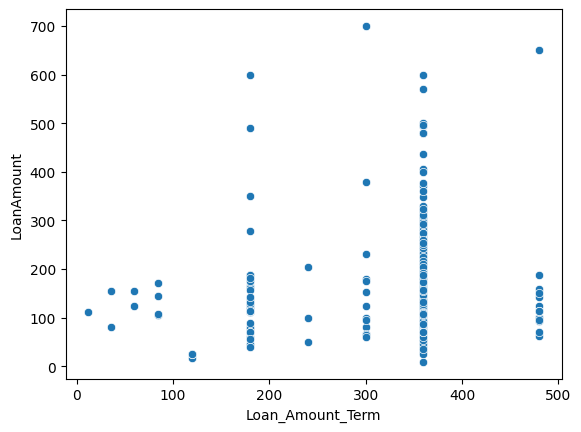

In [41]:
sns.scatterplot(x="Loan_Amount_Term", y="LoanAmount", data=df)
plt.show()

In [42]:
df[["total_income", "LoanAmount"]].corr()

,total_income,LoanAmount
total_income,1.000000,0.624621
LoanAmount,0.624621,1.000000


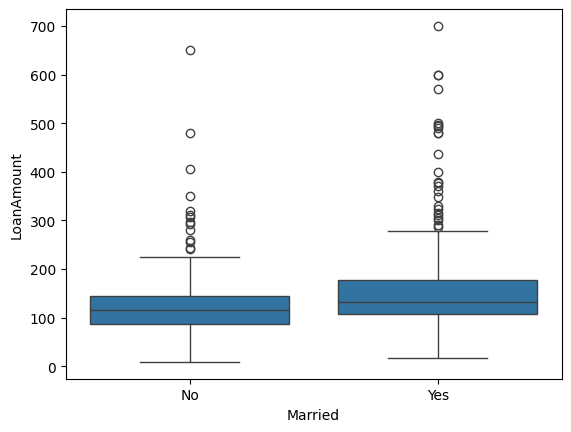

In [43]:
sns.boxplot(x="Married", y="LoanAmount", data=df)
plt.show()

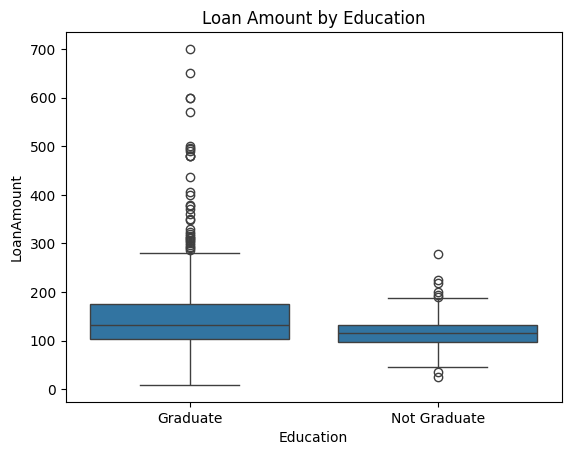

In [44]:
sns.boxplot(x="Education", y="LoanAmount", data=df)
plt.title("Loan Amount by Education")
plt.show()

In [45]:
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())

In [46]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Married"] = df["Married"].fillna(df["Married"].mode()[0])
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])

In [47]:
df.isnull().sum().sort_values(ascending=False)

,0
Loan_Amount_Term,14
Married,0
Gender,0
Dependents,0
Education,0
Self_Employed,0
LoanAmount,0
Credit_History,0
Property_Area,0
Loan_Status,0


In [48]:
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mean().round())

In [49]:
df.Loan_Amount_Term.isnull().sum()

np.int64(0)

In [50]:
df.head(10)

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,total_income
0,Male,No,0,Graduate,No,128.0,360.0,1.0,Urban,Y,5849.0
1,Male,Yes,1,Graduate,No,128.0,360.0,1.0,Rural,N,6091.0
2,Male,Yes,0,Graduate,Yes,66.0,360.0,1.0,Urban,Y,3000.0
3,Male,Yes,0,Not Graduate,No,120.0,360.0,1.0,Urban,Y,4941.0
4,Male,No,0,Graduate,No,141.0,360.0,1.0,Urban,Y,6000.0
5,Male,Yes,2,Graduate,Yes,267.0,360.0,1.0,Urban,Y,9613.0
6,Male,Yes,0,Not Graduate,No,95.0,360.0,1.0,Urban,Y,3849.0
7,Male,Yes,3+,Graduate,No,158.0,360.0,0.0,Semiurban,N,5540.0
8,Male,Yes,2,Graduate,No,168.0,360.0,1.0,Urban,Y,5532.0
9,Male,Yes,1,Graduate,No,349.0,360.0,1.0,Semiurban,N,23809.0


# Encoding

This section transforms categorical variables into a numerical format so that they can be used in machine learning models. Since most algorithms require numerical input, categorical features were encoded in a structured and interpretable way.

In [51]:
cat_columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='object')

In [52]:
df["Loan_Status"] = df["Loan_Status"].map({"Y": 1, "N": 0})

In [53]:
df.Loan_Status.head()

,Loan_Status
0,1
1,0
2,1
3,1
4,1


In [54]:
df = pd.get_dummies(df, drop_first=True)

In [55]:
df.columns.size

14

In [56]:
df

,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,total_income,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,128.0,360.0,1.0,1,5849.0,True,False,False,False,False,False,False,False,True
1,128.0,360.0,1.0,0,6091.0,True,True,True,False,False,False,False,False,False
2,66.0,360.0,1.0,1,3000.0,True,True,False,False,False,False,True,False,True
3,120.0,360.0,1.0,1,4941.0,True,True,False,False,False,True,False,False,True
4,141.0,360.0,1.0,1,6000.0,True,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,71.0,360.0,1.0,1,2900.0,False,False,False,False,False,False,False,False,False
610,40.0,180.0,1.0,1,4106.0,True,True,False,False,True,False,False,False,False
611,253.0,360.0,1.0,1,8312.0,True,True,True,False,False,False,False,False,True
612,187.0,360.0,1.0,1,7583.0,True,True,False,True,False,False,False,False,True


In [57]:
df = df.astype(int)

In [58]:
df.head()

,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,total_income,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,128,360,1,1,5849,1,0,0,0,0,0,0,0,1
1,128,360,1,0,6091,1,1,1,0,0,0,0,0,0
2,66,360,1,1,3000,1,1,0,0,0,0,1,0,1
3,120,360,1,1,4941,1,1,0,0,0,1,0,0,1
4,141,360,1,1,6000,1,0,0,0,0,0,0,0,1


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   LoanAmount               614 non-null    int64
 1   Loan_Amount_Term         614 non-null    int64
 2   Credit_History           614 non-null    int64
 3   Loan_Status              614 non-null    int64
 4   total_income             614 non-null    int64
 5   Gender_Male              614 non-null    int64
 6   Married_Yes              614 non-null    int64
 7   Dependents_1             614 non-null    int64
 8   Dependents_2             614 non-null    int64
 9   Dependents_3+            614 non-null    int64
 10  Education_Not Graduate   614 non-null    int64
 11  Self_Employed_Yes        614 non-null    int64
 12  Property_Area_Semiurban  614 non-null    int64
 13  Property_Area_Urban      614 non-null    int64
dtypes: int64(14)
memory usage: 67.3 KB


# train-test-split

In [60]:
from sklearn.model_selection import train_test_split

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify = y)

In [61]:
X.head()

,LoanAmount,Loan_Amount_Term,Credit_History,total_income,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,128,360,1,5849,1,0,0,0,0,0,0,0,1
1,128,360,1,6091,1,1,1,0,0,0,0,0,0
2,66,360,1,3000,1,1,0,0,0,0,1,0,1
3,120,360,1,4941,1,1,0,0,0,1,0,0,1
4,141,360,1,6000,1,0,0,0,0,0,0,0,1


In [62]:
y.head()

,Loan_Status
0,1
1,0
2,1
3,1
4,1


In [63]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((491, 13), (123, 13), (491,), (123,))

# Scaling For Logistic Regression

Feature scaling was applied only for models sensitive to feature magnitude, such as Logistic Regression.

Tree-based models such as Decision Tree and Random Forest were trained on the original feature values, since they do not require scaling.
Also not for all numerics.

In [64]:
df.head()

,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,total_income,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,128,360,1,1,5849,1,0,0,0,0,0,0,0,1
1,128,360,1,0,6091,1,1,1,0,0,0,0,0,0
2,66,360,1,1,3000,1,1,0,0,0,0,1,0,1
3,120,360,1,1,4941,1,1,0,0,0,1,0,0,1
4,141,360,1,1,6000,1,0,0,0,0,0,0,0,1


In [65]:
df.Loan_Amount_Term.value_counts()

,count
Loan_Amount_Term,
360,512
180,44
480,15
342,14
300,13
84,4
240,4
120,3
60,2


In [66]:
from sklearn.preprocessing import StandardScaler

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()

num_cols_scaler = ["LoanAmount", "Loan_Amount_Term", "total_income"]

X_train_scaled[num_cols_scaler] = scaler.fit_transform(X_train[num_cols_scaler])
X_test_scaled[num_cols_scaler] = scaler.transform(X_test[num_cols_scaler])

In [67]:
X_train_scaled.head()

,LoanAmount,Loan_Amount_Term,Credit_History,total_income,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
154,-1.131588,0.287739,1,-0.575167,1,0,0,0,0,0,0,0,1
239,-0.592309,0.287739,1,-0.566044,1,1,1,0,0,0,0,1,0
448,0.040758,0.287739,0,-0.306544,1,1,0,1,0,0,0,0,0
471,-0.393010,-2.482452,0,-0.440706,1,1,1,0,0,1,0,0,0
273,0.040758,0.287739,1,-0.337504,1,1,0,0,0,0,0,1,0


# Modelling

Three classification models were trained and evaluated using cross-validation and test metrics. Logistic Regression achieved the best overall balance across accuracy, recall, and F1-score.

In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [69]:
results = pd.DataFrame(columns=[
    "CV Mean Accuracy",
    "CV Std Accuracy",
    "Test Accuracy",
    "Precision",
    "Recall",
    "F1 Score"]);results

,CV Mean Accuracy,CV Std Accuracy,Test Accuracy,Precision,Recall,F1 Score


### Logistic Regression

In [70]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=10, scoring="accuracy")

results.loc["Logistic Regression"] = [
    scores.mean(),
    scores.std(),
    accuracy_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr)]

In [71]:
results

,CV Mean Accuracy,CV Std Accuracy,Test Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.796367,0.029996,0.853659,0.831683,0.988235,0.903226


### Decision Tree Classifier

In [72]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
scores = cross_val_score(dt_model, X_train, y_train, cv=10, scoring="accuracy")

results.loc["Decision Tree"] = [
    scores.mean(),
    scores.std(),
    accuracy_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_dt)]
results

,CV Mean Accuracy,CV Std Accuracy,Test Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.796367,0.029996,0.853659,0.831683,0.988235,0.903226
Decision Tree,0.666041,0.039449,0.731707,0.861111,0.729412,0.789809


### Random Forest Classifier

In [73]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
scores = cross_val_score(rf_model, X_train, y_train, cv=10, scoring="accuracy")

results.loc["Random Forest"] = [
    scores.mean(),
    scores.std(),
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf)]

results

,CV Mean Accuracy,CV Std Accuracy,Test Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.796367,0.029996,0.853659,0.831683,0.988235,0.903226
Decision Tree,0.666041,0.039449,0.731707,0.861111,0.729412,0.789809
Random Forest,0.757714,0.039675,0.829268,0.840426,0.929412,0.882682


Among the evaluated models, Logistic Regression achieved the best overall performance.

---


It produced the highest test accuracy, recall, and F1 score, indicating a
strong balance between correctly identifying approved loans and maintaining prediction consistency.

---


Random Forest also performed well, while Decision
Tree showed comparatively weaker generalization performance.

### Best Model Overview - Logistic Regression

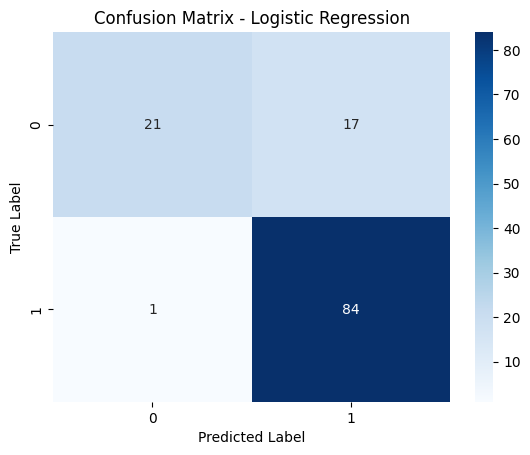

In [74]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [75]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.95      0.55      0.70        38
           1       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



### Grid Search

In [76]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
    "class_weight": [None, "balanced"]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=10,
    scoring="f1",
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)

print(grid_lr.best_params_)
print(grid_lr.best_score_)

{'C': 0.01, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}
0.8700758189179242


In [77]:
best_lr = grid_lr.best_estimator_
y_pred_best_lr = best_lr.predict(X_test_scaled)

tuned_results = pd.DataFrame(columns=[
    "Best CV F1",
    "Test Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
])

tuned_results.loc["Tuned Logistic Regression"] = [
    grid_lr.best_score_,
    accuracy_score(y_test, y_pred_best_lr),
    precision_score(y_test, y_pred_best_lr),
    recall_score(y_test, y_pred_best_lr),
    f1_score(y_test, y_pred_best_lr)
]

tuned_results

,Best CV F1,Test Accuracy,Precision,Recall,F1 Score
Tuned Logistic Regression,0.870076,0.853659,0.831683,0.988235,0.903226


In [78]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [2, 4]}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=10,
    scoring="f1",
    n_jobs=-1)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
0.8700758189179242


In [79]:
best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print("Precision:", precision_score(y_test, y_pred_best_rf))
print("Recall:", recall_score(y_test, y_pred_best_rf))
print("F1 Score:", f1_score(y_test, y_pred_best_rf))

Accuracy: 0.8536585365853658
Precision: 0.8316831683168316
Recall: 0.9882352941176471
F1 Score: 0.9032258064516129


In [80]:
(y_pred_rf == y_pred_best_rf).all()

np.False_

In [81]:
(y_pred_rf != y_pred_best_rf).sum()

np.int64(7)

In [82]:
tuned_results.loc["Tuned Random Forest"] = [
    grid_rf.best_score_,
    accuracy_score(y_test, y_pred_best_rf),
    precision_score(y_test, y_pred_best_rf),
    recall_score(y_test, y_pred_best_rf),
    f1_score(y_test, y_pred_best_rf)]

tuned_results

,Best CV F1,Test Accuracy,Precision,Recall,F1 Score
Tuned Logistic Regression,0.870076,0.853659,0.831683,0.988235,0.903226
Tuned Random Forest,0.870076,0.853659,0.831683,0.988235,0.903226


In [84]:
results

,CV Mean Accuracy,CV Std Accuracy,Test Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.796367,0.029996,0.853659,0.831683,0.988235,0.903226
Decision Tree,0.666041,0.039449,0.731707,0.861111,0.729412,0.789809
Random Forest,0.757714,0.039675,0.829268,0.840426,0.929412,0.882682


In [85]:
coef_df_default = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

coef_df_default.head()

,Feature,Coefficient
2,Credit_History,3.138548
11,Property_Area_Semiurban,0.727326
5,Married_Yes,0.507501
7,Dependents_2,0.330322
8,Dependents_3+,0.134579


In this project, the loan prediction dataset was explored, cleaned, and transformed before applying multiple classification algorithms. Among the evaluated models, Logistic Regression provided the best overall performance. Hyperparameter tuning was also tested, but it did not improve the final test metrics beyond the baseline Logistic Regression model. Overall, the results suggest that Credit_History and certain demographic or property-related variables are among the most influential predictors of loan approval.